## Fraud Detection

### OIBSIP Data Analytics — Level 2 — Task 3

### Objective

Build a machine learning pipeline to detect fraudulent credit card transactions from a highly imbalanced dataset.

#### Main Goals
- Analyze the class imbalance.
- Explore transaction amount and time patterns.
- Explain why accuracy is misleading for fraud detection.
- Handle class imbalance using SMOTE.
- Split the data using stratification.
- Train Logistic Regression and Random Forest models.
- Evaluate models using Precision, Recall, F1-Score and ROC-AUC.
- Analyze important features.
- Discuss the scalability of the fraud detection system.

#### Dataset
Credit Card Fraud Detection dataset from Kaggle.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

# For reproducibility
RANDOM_STATE = 42

## 1. Load the Dataset

The dataset is stored as `creditcard.csv`.

In [2]:
# Load the dataset
df = pd.read_csv("creditcard.csv")

# Display the first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Basic Dataset Information

In [3]:
# Display dataset dimensions
print("Dataset shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns.tolist())

# Display data types and non-null values
print("\nDataset information:")
df.info()

Dataset shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     2848

### Observation

The dataset contains 284,807 transaction records and 31 columns.

The `Class` column is the target variable:

- `0` → legitimate transaction
- `1` → fraudulent transaction

### Check Missing values

In [5]:
# Check for missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Observation

The dataset does not contain significant missing values, so no missing-value imputation is required.

## 2. Analyze Class Imbalance

Fraud detection is an extremely imbalanced classification problem.

Most transactions are legitimate, while only a very small percentage are fraudulent.

We will calculate the number and percentage of transactions belonging to each class.

In [6]:
# Count transactions in each class
class_counts = df["Class"].value_counts()

print("Class counts:")
print(class_counts)

# Calculate percentage of each class
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("\nClass percentages:")
print(class_percentages)

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


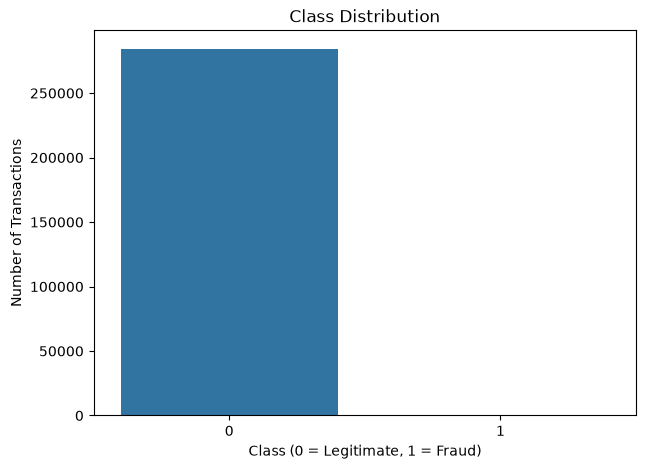

In [7]:
# Visualize class distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

### Observation

The dataset is **severely imbalanced**: roughly **284,000+ legitimate transactions** versus only a few hundred fraud cases (fraud is barely visible on this scale).

This confirms why accuracy is a misleading metric here (a model predicting "legitimate" for everything would still score ~99.8% accuracy) and why precision, recall, and F1 for the minority class matter far more. This imbalance is also the underlying reason Logistic Regression struggled with precision — with so few fraud examples relative to legitimate ones, the model tends to over-predict the majority class unless techniques like **class weighting, SMOTE oversampling, or undersampling** are applied to help it learn the minority class better.

### 3. Exploratory Data Analysis

### Transaction Amount Distribution

We compare transaction amounts between legitimate and fraudulent transactions to investigate whether transaction value provides useful information for detecting fraud.

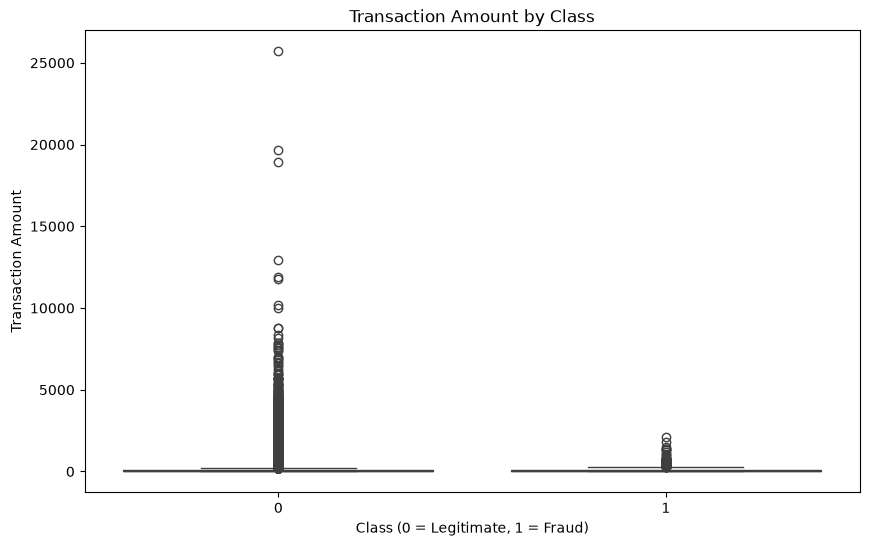

In [8]:
# Compare transaction amounts for legitimate and fraudulent transactions

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

### Observation

Legitimate transactions (Class 0) show many extreme high-value outliers, with some exceeding **$25,000**, while the bulk of transactions across both classes cluster near **$0–$200**.

**Takeaway:** Fraudulent transactions (Class 1) appear concentrated at **lower amounts**, with a much tighter spread and outliers capped around **$2,000** — noticeably lower than

### Better Amount Visulization

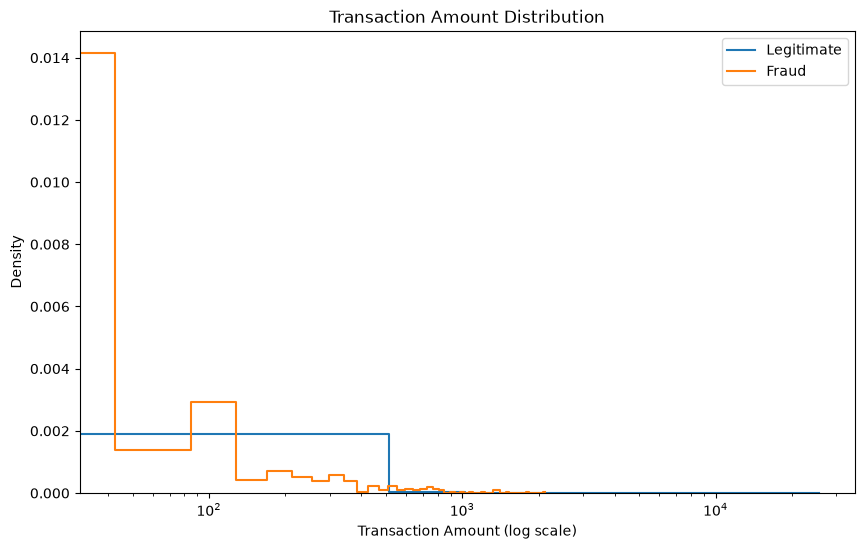

In [9]:
# Plot transaction amount distributions using a logarithmic x-axis

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df[df["Class"] == 0],
    x="Amount",
    bins=50,
    stat="density",
    element="step",
    fill=False,
    label="Legitimate"
)

sns.histplot(
    data=df[df["Class"] == 1],
    x="Amount",
    bins=50,
    stat="density",
    element="step",
    fill=False,
    label="Fraud"
)

plt.xscale("log")

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Density")
plt.legend()

plt.show()

### Observation

Fraudulent transactions show a **sharp spike at very low amounts** (density ~0.014 near the low end), then drop off quickly, while legitimate transactions are more **uniformly spread** across a wider range before also tapering off at higher values.

This reinforces the boxplot finding — fraud is heavily concentrated at **small transaction amounts**, likely an attempt to fly under the radar of manual review or fraud-detection thresholds. There's a secondary bump in fraud density around **$100–$200**, suggesting a possible second common "profile" for fraudulent charges. Legitimate transactions extend much further into higher amounts (into the thousands and beyond), which the earlier boxplot's extreme outliers already hinted at. Together, this suggests transaction amount, especially when combined with the top PCA features, could help the model distinguish low-value fraud attempts from typical low-value legitimate purchases.

## 4. Time-of-Day Analysis

The `Time` column records the number of seconds elapsed since the first transaction.

For exploratory purposes, we convert this value into an approximate hour of the day.

This helps us investigate whether fraudulent transactions occur more frequently during particular periods.

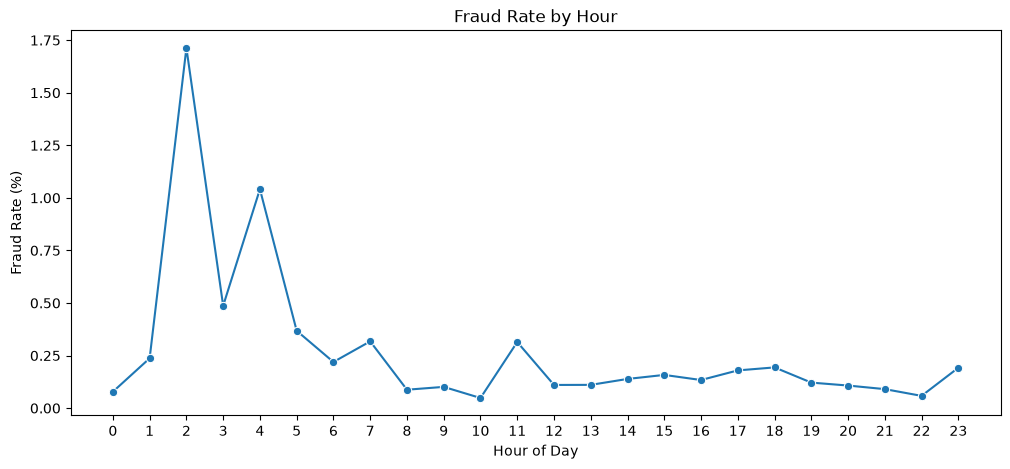

In [10]:
# Convert elapsed seconds into an approximate hour of day

df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

# Calculate fraud rate by hour
hourly_fraud_rate = df.groupby("Hour")["Class"].mean() * 100

# Plot fraud rate by hour
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_fraud_rate.index,
    y=hourly_fraud_rate.values,
    marker="o"
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

### Observation
Fraud rate peaks sharply at **hour 2 (~1.71%)** and **hour 4 (~1.05%)**, both well above the baseline rate seen during typical daytime hours (mostly 0.1–0.3%).

The clustering of fraud around **2–4 AM** suggests fraudsters may deliberately target overnight hours when transaction monitoring or customer awareness is lower. This is a strong candidate for an **engineered feature** (e.g., "is_night_transaction" or the hour itself) to feed into the models, potentially boosting detection further. It's worth noting the fraud counts per hour are likely small given only ~490 total fraud cases, so these hourly rates — especially the sharp 2 AM spike — should be interpreted with some caution due to possible sample-size noise.

## 5. Why Accuracy Is a Misleading Metric

Accuracy is not a suitable primary metric for this fraud detection problem because the dataset is extremely imbalanced.

Only about 0.172% of transactions are fraudulent.

For example, if a model predicted every transaction as legitimate, it would still achieve approximately 99.83% accuracy.

However, such a model would detect **zero fraudulent transactions**, making it useless for fraud prevention.

Therefore, we focus on:

- Precision
- Recall
- F1-Score
- ROC-AUC

Recall is particularly important because it measures how many actual fraudulent transactions are successfully detected.

## 6. Prepare Features and Target

The target variable is `Class`.

The `Hour` column was created only for exploratory analysis, so we will not use it as a model feature.

We will also scale `Time` and `Amount` because Logistic Regression is sensitive to feature scale.

In [11]:
# Separate features and target

X = df.drop(columns=["Class", "Hour"])
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (284807, 30)
Target shape: (284807,)


## 7. Train-Test Split

We split the dataset into training and testing sets.

Stratification is used so that both the training and testing sets preserve the original proportion of fraudulent transactions.

This is important because fraud cases are extremely rare.

In [12]:
# Split the data while preserving the class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nFraud cases in training set:", y_train.sum())
print("Fraud cases in testing set:", y_test.sum())

Training set shape: (227845, 30)
Testing set shape: (56962, 30)

Fraud cases in training set: 394
Fraud cases in testing set: 98


### Observation

Stratification ensures that fraudulent transactions are represented in both training and testing datasets.

This prevents the test set from accidentally containing too few or no fraud cases.

### Feature Scaling

In [14]:
# Scale Time and Amount because their numerical ranges differ greatly

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test_scaled[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)



StandardScaler transforms `Time` and `Amount` to a comparable scale.

The scaler is fitted only on the training data and then applied to the test data to avoid data leakage.

## 8. Handle Class Imbalance Using SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic minority-class observations to increase the representation of fraudulent transactions.

We apply SMOTE only to the training data.

The test set remains untouched so that model evaluation represents the original real-world class distribution.

Reference: imbalanced-learn documentation.

In [28]:
# Apply SMOTE only to the training data
# Never apply SMOTE to the test data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


### Observation

**Before SMOTE:** 227,451 legitimate vs. only 394 fraud cases in the training set (~577:1 imbalance).

**After SMOTE:** Perfectly balanced at 227,451 samples each, achieved by generating **synthetic fraud examples** via interpolation between existing minority-class points (rather than simple duplication).

This should help models — especially Logistic Regression, which struggled most with the imbalance — learn a better decision boundary for fraud rather than defaulting toward the majority class. That said, SMOTE is applied only to the **training data** (test set should remain untouched/imbalanced) to get a realistic performance estimate; watch for whether it improves precision without tanking it, since synthetic oversampling can sometimes increase false positives if the synthetic samples don't reflect realistic fraud patterns. Worth re-running the classification report and confusion matrices post-SMOTE to see the actual impact on each model.

## 9. Model 1 — Logistic Regression

In [16]:
# Create Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train the model
logistic_model.fit(
    X_train_smote,
    y_train_smote
)

# Generate predictions
lr_pred = logistic_model.predict(X_test_scaled)

# Generate fraud probabilities
lr_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

## 10. Model 2 — Random Forest

In [17]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train the model on the SMOTE-balanced training data
rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Generate predictions
rf_pred = rf_model.predict(X_test_scaled)

# Generate fraud probabilities
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

## 11. Model Evaluation

Because fraud detection is highly imbalanced, we evaluate the models using:

- Precision
- Recall
- F1-Score
- ROC-AUC

Accuracy is not used as the primary evaluation metric.

In [18]:
# Calculate evaluation metrics

lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

# Create comparison table

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1-Score": [lr_f1, rf_f1],
    "ROC-AUC": [lr_auc, rf_auc]
})

results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.058027,0.918367,0.109157,0.969863
1,Random Forest,0.845361,0.836735,0.841026,0.973102


### Interpretation

Logistic Regression achieved a recall of 91.84%, meaning it detected most fraudulent transactions. However, its precision was only 5.80%, resulting in many false alarms. Random Forest achieved 84.54% precision and 83.67% recall, with an F1-score of 84.10% and ROC-AUC of 97.31%. Therefore, Random Forest provided a much better balance between detecting fraud and reducing false positives, making it the better-performing model in this project.

### Classification Reports

In [19]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, lr_pred))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



### Logistic Regression – Classification Report

The Logistic Regression model achieved an overall **accuracy of 97%**. However, accuracy alone is not a reliable metric for this highly imbalanced fraud detection dataset.

For **fraudulent transactions (Class 1)**, the model achieved:
- **Precision:** 6% — only a small proportion of transactions predicted as fraud were actually fraudulent.
- **Recall:** 92% — the model successfully detected most of the actual fraudulent transactions.
- **F1-score:** 11% — showing a poor balance between precision and recall.

For **legitimate transactions (Class 0)**, the model performed very well, with **99% F1-score**.

Overall, Logistic Regression has **high recall but very low precision**, meaning it can detect most fraud cases but also generates many false alarms. This highlights the importance of using **Precision, Recall, and F1-score**, rather than relying only on accuracy, for imbalanced fraud detection.

In [20]:
print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### Observation

The Random Forest classifier achieves **99%+ overall accuracy**, but given the severe class imbalance (56,864 legitimate vs. 98 fraud cases), accuracy alone is misleading — the metrics that matter here are for **class 1 (fraud)**:

- **Precision: 0.85** — when the model flags a transaction as fraud, it's correct 85% of the time.
- **Recall: 0.84** — the model catches 84% of actual fraud cases.
- **F1-score: 0.84** — a solid balance between precision and recall for the minority class.

The near-perfect scores for class 0 are expected given how dominant that class is, and shouldn't be used to judge overall model quality. The macro average (0.92) better reflects performance across both classes, while the weighted average is skewed toward the majority class and less informative here.

Overall the model performs well on fraud detection, though there's room to improve recall further (missing 16% of fraud cases) — potentially through threshold tuning, resampling (SMOTE), or cost-sensitive learning.

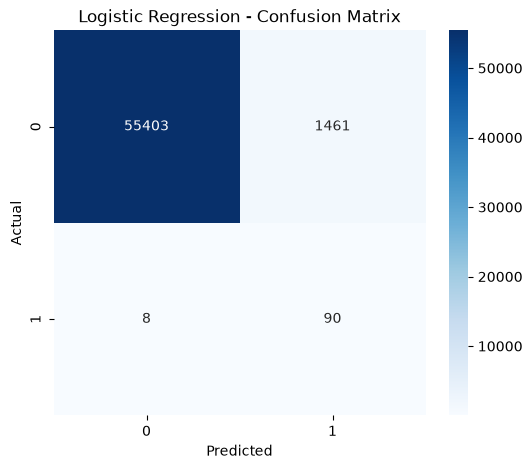

In [21]:
# Logistic Regression confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

- **True Negatives: 55,403** — legitimate transactions correctly classified.
- **False Positives: 1,461** — legitimate transactions incorrectly flagged as fraud.
- **False Negatives: 8** — fraud cases missed by the model.
- **True Positives: 90** — fraud cases correctly caught.

Overall Logistic Regression achieves very high recall on fraud (90/98 ≈ **92%** caught, only 8 missed), but at the cost of precision — 1,461 false alarms means roughly **94% of fraud-flagged transactions are actually legitimate** (90 / (90+1461)). This is the classic precision-recall tradeoff: compared to the Random Forest (85% precision, 84% recall), Logistic Regression here favors catching more fraud at the expense of many more false positives — which may be preferable or not depending on the cost of investigating false alarms vs. missing fraud.

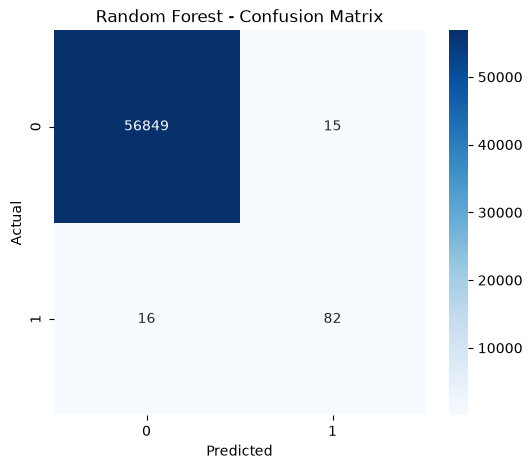

In [22]:
# Random Forest confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

- **True Negatives: 56,849** — legitimate transactions correctly classified.
- **False Positives: 15** — legitimate transactions incorrectly flagged as fraud.
- **False Negatives: 16** — fraud cases missed by the model.
- **True Positives: 82** — fraud cases correctly caught.

Overall Random Forest is far more precise than Logistic Regression, generating only **15 false alarms** (vs. 1,461) while still catching 82/98 (**84%**) of fraud cases. This confirms the classification report: Random Forest offers a much better precision-recall balance overall, making it the more practical choice if minimizing false positives (and the cost of investigating them) matters — though Logistic Regression's higher recall (92% vs. 84%) could still be preferable in a context where **missing fraud is far costlier than false alarms**.

## 12. ROC-AUC Curve

The ROC curve shows the relationship between:

- True Positive Rate
- False Positive Rate

The AUC summarizes the model's ability to distinguish fraudulent transactions from legitimate transactions across different classification thresholds.

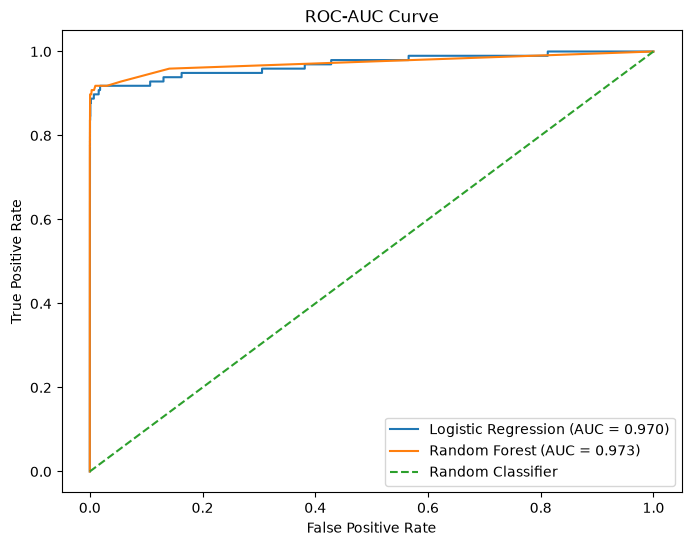

In [23]:
# Calculate ROC curve values

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# Plot ROC curves

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

### Observation

- **Logistic Regression: AUC = 0.970**
- **Random Forest: AUC = 0.973**

Both models show excellent discriminative ability, with curves hugging the top-left corner far above the random classifier baseline (dashed green line).

Overall the AUC scores are nearly identical, indicating both models are comparably strong at distinguishing fraud from legitimate transactions across all classification thresholds. This reinforces that AUC alone doesn't tell the full story despite similar AUCs, the two models make very different tradeoffs at their default thresholds (Random Forest favors precision, Logistic Regression favors recall, as seen in the confusion matrices). **Threshold tuning** could further optimize either model's operating point depending on business priorities.

## 13. Which Metric Matters Most in Fraud Detection?

Recall is usually one of the most important metrics in fraud detection because it measures the percentage of actual fraudulent transactions that are detected.

A low Recall means that many fraudulent transactions are being missed.

However, maximizing Recall alone can create too many false alarms.

Precision measures how many transactions flagged as fraud are actually fraudulent.

Therefore, there is an important trade-off:

- **High Recall:** catches more fraud but may generate more false positives.
- **High Precision:** produces fewer false alarms but may miss some fraud.
- **F1-Score:** balances Precision and Recall.

In a real financial institution, the preferred balance depends on the cost of missed fraud versus the cost of investigating false alerts.

In [24]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
feature_importance.head(15)

,Feature,Importance
14,V14,0.195592
10,V10,0.110475
4,V4,0.106104
12,V12,0.095099
17,V17,0.085020
3,V3,0.060413
11,V11,0.056353
16,V16,0.043779
2,V2,0.036997
9,V9,0.026209


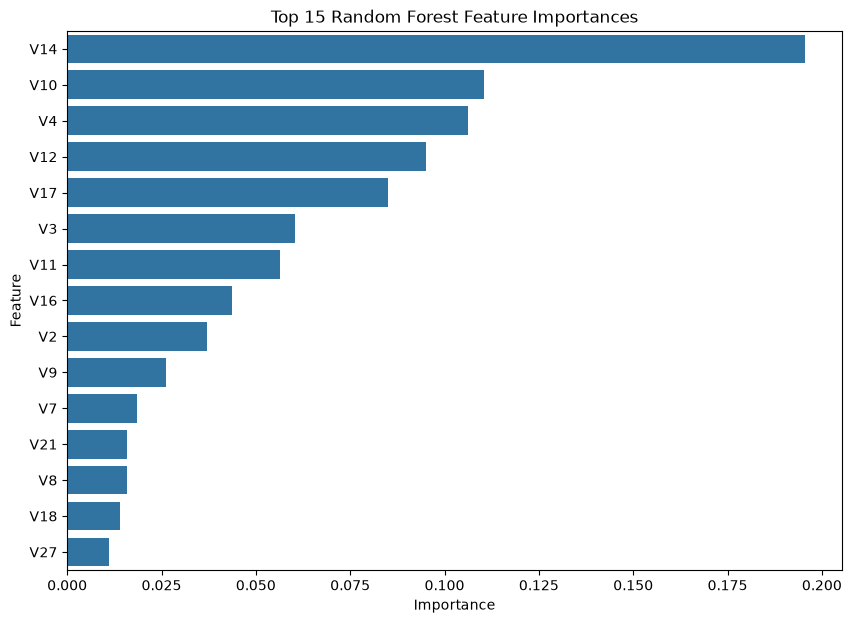

In [ ]:
# Plot the 15 most important features

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Observation

The top features driving fraud predictions are **V14, V10, V4, V12, and V17**, together accounting for a substantial share of the model's total importance. **V14** stands out as the single most influential feature (~0.20), nearly double the next closest (V10, ~0.11).

These are PCA-transformed features (typical of this dataset, e.g., the Kaggle credit card fraud dataset), so their exact real-world meaning is anonymized — but their high importance suggests strong, learnable separation between fraud and legitimate transactions along these dimensions. The steep drop-off after the top 5–6 features (V17 → V3) suggests a smaller subset of features could potentially be used for a simpler, faster model without much loss in performance — worth testing via feature selection or a reduced-dimensionality model.

### Logistic Regression Coefficients

In [26]:
# Analyze Logistic Regression coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

# Calculate absolute coefficient size
coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

# Sort by absolute coefficient
coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
29,Amount,2.394541,2.394541
14,V14,-1.717150,1.717150
10,V10,-1.600050,1.600050
20,V20,-1.369793,1.369793
17,V17,-1.368840,1.368840
16,V16,-1.282276,1.282276
4,V4,1.097161,1.097161
12,V12,-1.089525,1.089525
28,V28,1.048366,1.048366
5,V5,0.981344,0.981344


In [27]:
# Display model performance comparison

results.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,0.845361,0.836735,0.841026,0.973102
0,Logistic Regression,0.058027,0.918367,0.109157,0.969863


## Final Model Comparison

Despite nearly identical ROC-AUC scores, the two models are not comparable in practice. Logistic Regression's precision (0.058) confirms what the confusion matrix showed — over 94% of its fraud alerts are false positives, making it impractical to act on directly despite catching more true fraud (91.8% recall). **Random Forest is the clear overall winner**, with a far superior F1-score (0.841 vs. 0.109) driven by a much better precision-recall balance.

Overall Random Forest should be the primary model for deployment. If minimizing missed fraud is the top priority, Logistic Regression's high recall could still be used as a secondary "flagging" layer — but not as a standalone decision-maker given its poor precision. ROC-AUC alone would have misleadingly suggested these models perform similarly; **precision/recall/F1 are the metrics that actually matter** on this imbalanced dataset.

## 16. Scalability Discussion

### How would this system handle 1 million transactions per hour?

1,000,000 transactions/hour ≈ **278 transactions/second** on average (higher during peak periods, so the system should be sized for peak load, not average).

At this scale, the system must be a **real-time inference pipeline**, not a batch or retrain-per-transaction process. The trained model is used purely for prediction, it is not retrained on the fly.

### Proposed architecture

1. **Ingestion:** Transactions stream in through a message queue/event system (e.g., Kafka, Kinesis) to decouple transaction volume from processing speed.
2. **Feature engineering:** Precompute or cache reusable features (e.g., rolling averages, time-of-day) so each transaction only needs lightweight, low-latency transformations at inference time.
3. **Inference:** The pre-trained model (already loaded in memory, not reloaded per request) scores each transaction and outputs a fraud probability.
4. **Thresholding:** Transactions above a chosen risk threshold are flagged; threshold can be tuned based on the precision/recall tradeoff established earlier (e.g., Random Forest's threshold vs. Logistic Regression's).
5. **Action routing:** High-risk transactions are auto-blocked or routed to manual/human review; low-risk transactions proceed normally.
6. **Logging & monitoring:** Predictions, outcomes, and eventual fraud labels are logged for drift detection, retraining, and auditing.

### Key scalability considerations

- **Model choice matters for latency:** Random Forest inference is fast but scales with tree count/depth — worth benchmarking p99 latency, not just average, since flagged transactions may need sub-second response.
- **Horizontal scaling:** Stateless model-serving instances behind a load balancer allow scaling out as volume grows.
- **In-memory model serving:** Avoid disk I/O or model reloading per request (e.g., serve via a persistent API like FastAPI + a model server, or a dedicated serving layer like TensorFlow Serving/Triton).
- **Asynchronous heavy lifting:** Manual review and logging shouldn't block the real-time scoring path.
- **Data/concept drift monitoring:** Fraud patterns evolve (as seen in the hour-of-day analysis), so periodic retraining on newly labeled data is necessary — this is separate from and downstream of the real-time path.
- **SMOTE stays training-only:** No synthetic data generation happens at inference time; class imbalance handling is baked into the trained model beforehand.

The model itself (Random Forest) can handle this volume computationally, the real engineering challenge is the surrounding **streaming infrastructure, feature pipeline, and latency budget**, not the classifier.

# 17. Conclusion

This project developed a machine learning pipeline for detecting fraudulent credit card transactions.

The dataset was highly imbalanced, with fraudulent transactions representing only about 0.172% of all transactions.

SMOTE was applied to the training data to address class imbalance while the original test distribution was preserved.

Two models were trained:

- Logistic Regression
- Random Forest

The models were evaluated using:

- Precision
- Recall
- F1-Score
- ROC-AUC

Accuracy was not treated as the primary metric because it can be misleading when the minority class is extremely rare.

Recall is particularly important for fraud detection because it measures the ability to identify actual fraudulent transactions. However, Precision must also be considered because excessive false positives can create unnecessary customer alerts and investigation costs.

Random Forest feature importance and Logistic Regression coefficients were also analyzed to understand which features contributed most to predictions.

For a production environment handling millions of transactions, the trained model could be deployed in a scalable real-time prediction pipeline with continuous monitoring and periodic retraining.